<a href="https://colab.research.google.com/github/dellae09/academic-performance-clustering-kmeans-sa/blob/main/05_Modeling_Capaian_Akademik_KMeans_SA_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# CRISP-DM BAB IV:
# 4.1 Business Understanding
# 4.2 Data Understanding
# 4.3 Data Preparation
# 4.4 Modeling (K-Means Standard & K-Means + SA)
# 4.5 Evaluation
# 4.6 Deployment
# ============================================================

***Cell 1 — Mount Drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***[CELL 02] Import Library + Path Output***

In [ ]:
import os, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.stats import chi2

from IPython.display import display

IN_FILE = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/final/capaian_akademik_master_pre_post_ujian_2025.csv"

OUT_STD_DIR = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR"
OUT_SA_DIR  = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING"
os.makedirs(OUT_STD_DIR, exist_ok=True)
os.makedirs(OUT_SA_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# kandidat K untuk Elbow/Evaluasi awal
K_MIN, K_MAX = 2, 8

In [ ]:
# ============================================================
# Helper: simpan figure
# ============================================================
def save_fig(path: str):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

def norm_text(x):
    if pd.isna(x): return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def read_csv_safely(path: str) -> pd.DataFrame:
    # dataset final biasanya comma, tapi tetap aman
    for sep in [",",";","\t","|"]:
        try:
            df = pd.read_csv(path, dtype=str, sep=sep, engine="python")
            if df.shape[1] > 1:
                return df
        except:
            pass
    raise RuntimeError("Gagal membaca dataset input.")

def profile_df(df: pd.DataFrame, title: str, out_csv: str = None, top_n=15):
    print("="*110)
    print(title)
    print("="*110)
    print("Shape:", df.shape)
    print("\nKolom:")
    for i,c in enumerate(df.columns,1):
        print(f"{i:02d}. {c}")

    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype").reset_index().rename(columns={"index":"Kolom"}))

    print("\nPreview 10 baris:")
    display(df.head(10))

    prof = pd.DataFrame({
        "Kolom": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "Missing_Count": [int(df[c].isna().sum()) for c in df.columns],
        "Missing_Rate": [float(df[c].isna().mean()) for c in df.columns],
        "Unique_Count": [int(df[c].nunique(dropna=True)) for c in df.columns],
        "Contoh_Nilai": [
            df[c].dropna().astype(str).head(1).iloc[0] if df[c].dropna().shape[0] else ""
            for c in df.columns
        ],
    }).sort_values(["Missing_Rate","Unique_Count"], ascending=[False, False])

    display(prof)

    miss = df.isna().mean().sort_values(ascending=False).head(top_n)
    plt.figure()
    miss.plot(kind="bar")
    plt.title(f"Missing Rate Top {top_n} — {title}")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

    if out_csv:
        prof.to_csv(out_csv, index=False)
        print("Saved profile:", out_csv)

    return prof


# 4.1 BUSINESS UNDERSTANDING (Markdown/penjelasan)

**4.1 Business Understanding**
- Tujuan: Membentuk klaster capaian akademik mahasiswa (pretest, posttest, ujian) sebagai profil segmentasi.
- Fitur (p=3): [Nilai_Pretest, Nilai_Posttest, Nilai_Ujian] sehingga tiap mahasiswa x_i adalah vektor berdimensi p=3.
- K-Means meminimalkan fungsi objektif (2.1):
  J = Σ_{j=1..K} Σ_{x_i∈C_j} ||x_i - μ_j||^2
  (SSE / inertia scikit-learn)
- Jarak Euclidean (2.2) digunakan untuk assignment.
- Centroid update (2.3) = rata-rata anggota klaster.
- Karena K-Means sensitif inisialisasi, dilakukan optimasi Simulated Annealing (SA):
  ΔE (2.4), probabilitas penerimaan (2.5), cooling schedule (2.6).
Output: dua model (Standar vs +SA) + evaluasi internal (SSE, Silhouette, DBI).


***CELL 03 — Load Dataset Master***

In [ ]:
df_raw = read_csv_safely(IN_FILE)
print("Loaded:", df_raw.shape)

Loaded: (156, 5)


# 4.2 DATA UNDERSTANDING

***CELL 04 — Profil Data Awal (tabel + diagram)***

4.2 DATA UNDERSTANDING — DATASET MASTER (RAW)
Shape: (156, 5)

Kolom:
01. NPM
02. Nama
03. Nilai_Pretest
04. Nilai_Posttest
05. Nilai_Ujian

Dtypes:


,Kolom,dtype
0,NPM,object
1,Nama,object
2,Nilai_Pretest,object
3,Nilai_Posttest,object
4,Nilai_Ujian,object



Preview 10 baris:


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14
1,G1F022002,Ulfa,38.89,33.33,48.0
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.0
4,G1F022008,Meisy Dianita,88.89,88.89,84.0
5,G1F022013,ANNAS ZAM ZAM,80.56,36.11,64.0
6,G1F022014,Tanya Dwi Agustin,50.0,72.22,64.0
7,G1F022016,Epriantravolta Saragih,81.25,87.5,47.62
8,G1F022019,Della Erlina,77.78,80.56,80.0
9,G1F022020,Ahmad Ilham Febryadi,69.44,72.22,56.0


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
0,NPM,object,0,0.0,156,G1F021045
1,Nama,object,0,0.0,156,Ananda Naila Evril
2,Nilai_Pretest,object,0,0.0,108,78.12
3,Nilai_Posttest,object,0,0.0,108,40.62
4,Nilai_Ujian,object,0,0.0,107,57.14


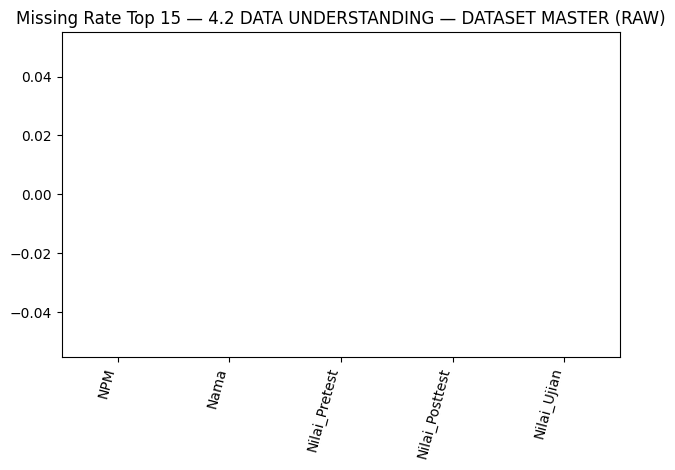

Saved profile: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/00_profile_raw_master.csv
Duplikasi NPM (raw): 0
Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/01_hist_raw.png


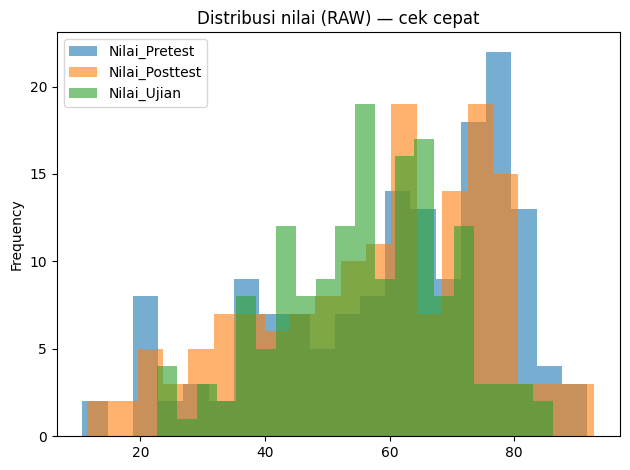

In [ ]:
OUT_PROFILE_RAW = os.path.join(OUT_STD_DIR, "00_profile_raw_master.csv")
_ = profile_df(df_raw, "4.2 DATA UNDERSTANDING — DATASET MASTER (RAW)", out_csv=OUT_PROFILE_RAW)

# Cek duplikasi NPM
if "NPM" in df_raw.columns:
    dup_npm = int(df_raw["NPM"].duplicated().sum())
    print("Duplikasi NPM (raw):", dup_npm)

# Histogram awal (kalau numeric sudah)
plt.figure()
for col in ["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian","Nilai_Ujia"]:
    if col in df_raw.columns:
        x = pd.to_numeric(df_raw[col], errors="coerce").dropna()
        if len(x)>0:
            x.plot(kind="hist", bins=20, alpha=0.6, label=col)
plt.title("Distribusi nilai (RAW) — cek cepat")
plt.legend()
save_fig(os.path.join(OUT_STD_DIR, "01_hist_raw.png"))
plt.show()

# 4.3 DATA PREPARATION

***CELL 05 — Standarisasi kolom + validasi nilai + bersihkan***

4.3 DATA PREPARATION — sebelum filter kelengkapan
Missing nilai (sebelum):


,Missing_Count
Nilai_Pretest,0
Nilai_Posttest,0
Nilai_Ujian,0


Filter lengkap 3 nilai -> sebelum: 156 | sesudah: 156 | tercoret: 0
Baris out-of-range 0–100: 0
Duplikasi NPM (setelah filter): 0
Saved clean modeling dataset: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/03_dataset_modeling_clean.csv
4.3 DATA PREPARATION — DATASET SIAP MODELING (CLEAN)
Shape: (156, 5)

Kolom:
01. NPM
02. Nama
03. Nilai_Pretest
04. Nilai_Posttest
05. Nilai_Ujian

Dtypes:


,Kolom,dtype
0,NPM,object
1,Nama,object
2,Nilai_Pretest,float64
3,Nilai_Posttest,float64
4,Nilai_Ujian,float64



Preview 10 baris:


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14
1,G1F022002,Ulfa,38.89,33.33,48.00
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.00
4,G1F022008,Meisy Dianita,88.89,88.89,84.00
5,G1F022013,ANNAS ZAM ZAM,80.56,36.11,64.00
6,G1F022014,Tanya Dwi Agustin,50.00,72.22,64.00
7,G1F022016,Epriantravolta Saragih,81.25,87.50,47.62
8,G1F022019,Della Erlina,77.78,80.56,80.00
9,G1F022020,Ahmad Ilham Febryadi,69.44,72.22,56.00


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
0,NPM,object,0,0.0,156,G1F021045
1,Nama,object,0,0.0,156,Ananda Naila Evril
2,Nilai_Pretest,float64,0,0.0,108,78.12
3,Nilai_Posttest,float64,0,0.0,108,40.62
4,Nilai_Ujian,float64,0,0.0,107,57.14


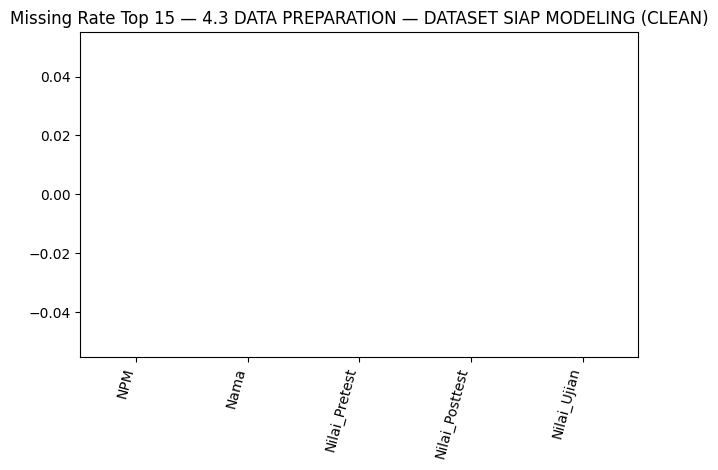

Saved profile: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/04_profile_clean.csv
Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/05_scatter_Nilai_Pretest_vs_Nilai_Posttest.png


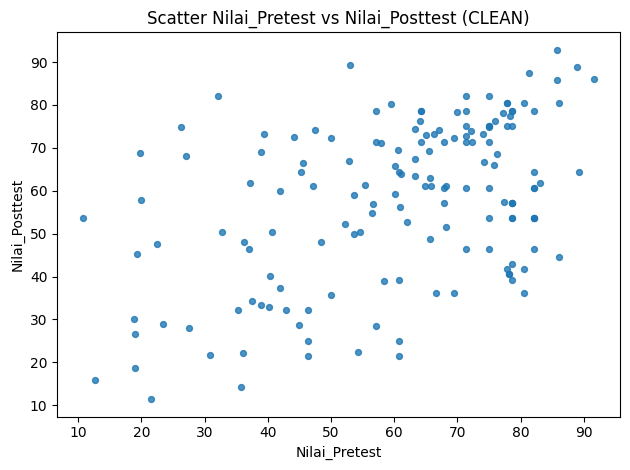

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/05_scatter_Nilai_Pretest_vs_Nilai_Ujian.png


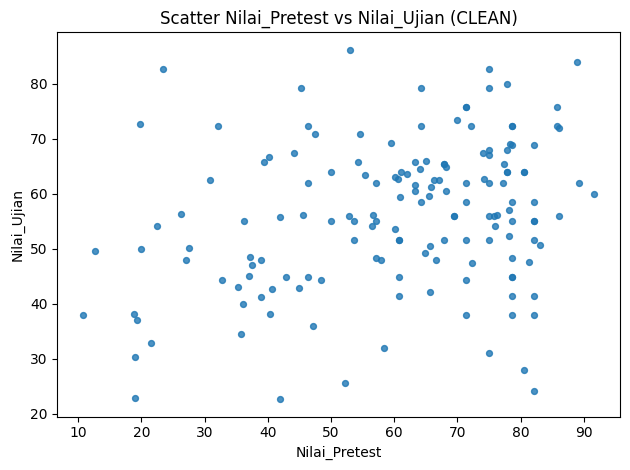

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/05_scatter_Nilai_Posttest_vs_Nilai_Ujian.png


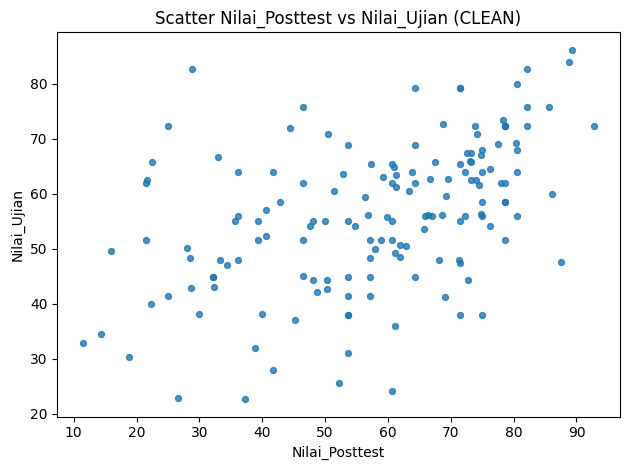

In [ ]:
df = df_raw.copy()

# rapikan kolom wajib
df.columns = [norm_text(c) for c in df.columns]

# amankan kasus kolom ujian terpotong
if "Nilai_Ujian" not in df.columns and "Nilai_Ujia" in df.columns:
    df = df.rename(columns={"Nilai_Ujia":"Nilai_Ujian"})

required = ["NPM","Nama","Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Kolom wajib tidak ada: {missing}. Kolom tersedia: {list(df.columns)}")

# normalisasi teks
df["NPM"]  = df["NPM"].apply(norm_text).str.upper()
df["Nama"] = df["Nama"].apply(norm_text)

# parsing numeric
for c in ["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("="*110)
print("4.3 DATA PREPARATION — sebelum filter kelengkapan")
print("="*110)
print("Missing nilai (sebelum):")
display(df[["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]].isna().sum().to_frame("Missing_Count"))

# (sesuai aturan kamu) wajib lengkap di tiga nilai
before = df.shape[0]
df = df.dropna(subset=["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]).copy()
after = df.shape[0]
print("Filter lengkap 3 nilai -> sebelum:", before, "| sesudah:", after, "| tercoret:", before-after)

# validasi range 0-100 (tidak mengubah kecuali kamu ingin clip)
out_range = (
    (df["Nilai_Pretest"]<0)|(df["Nilai_Pretest"]>100)|
    (df["Nilai_Posttest"]<0)|(df["Nilai_Posttest"]>100)|
    (df["Nilai_Ujian"]<0)|(df["Nilai_Ujian"]>100)
)
print("Baris out-of-range 0–100:", int(out_range.sum()))

OUT_BAD_RANGE = os.path.join(OUT_STD_DIR, "02_report_out_of_range.csv")
if out_range.any():
    df.loc[out_range, ["NPM","Nama","Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]].to_csv(OUT_BAD_RANGE, index=False)
    print("Saved report out-of-range:", OUT_BAD_RANGE)

# duplikasi NPM (harus 0). Jika ada, ambil mean (opsional) atau drop duplicates.
dup_npm = int(df["NPM"].duplicated().sum())
print("Duplikasi NPM (setelah filter):", dup_npm)
if dup_npm > 0:
    # pilih kebijakan aman: agregasi mean per NPM (jarang terjadi, tapi aman)
    df = (df.groupby(["NPM"], as_index=False)
            .agg(Nama=("Nama", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
                 Nilai_Pretest=("Nilai_Pretest","mean"),
                 Nilai_Posttest=("Nilai_Posttest","mean"),
                 Nilai_Ujian=("Nilai_Ujian","mean")))
    print("Duplikasi NPM disatukan (mean). Shape baru:", df.shape)

# simpan dataset siap modeling
OUT_CLEAN = os.path.join(OUT_STD_DIR, "03_dataset_modeling_clean.csv")
df.to_csv(OUT_CLEAN, index=False)
print("Saved clean modeling dataset:", OUT_CLEAN)

# profil setelah preparation
OUT_PROFILE_CLEAN = os.path.join(OUT_STD_DIR, "04_profile_clean.csv")
_ = profile_df(df, "4.3 DATA PREPARATION — DATASET SIAP MODELING (CLEAN)", out_csv=OUT_PROFILE_CLEAN)

# Scatter awal antar peubah (padanan ggscatter)
pairs = [("Nilai_Pretest","Nilai_Posttest"), ("Nilai_Pretest","Nilai_Ujian"), ("Nilai_Posttest","Nilai_Ujian")]
for a,b in pairs:
    plt.figure()
    plt.scatter(df[a], df[b], s=18, alpha=0.8)
    plt.xlabel(a); plt.ylabel(b)
    plt.title(f"Scatter {a} vs {b} (CLEAN)")
    save_fig(os.path.join(OUT_STD_DIR, f"05_scatter_{a}_vs_{b}.png"))
    plt.show()

***CELL 06 — Korelasi + Corrplot + Bartlett Test of Sphericity (PCA readiness)***

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/06_corrplot.png


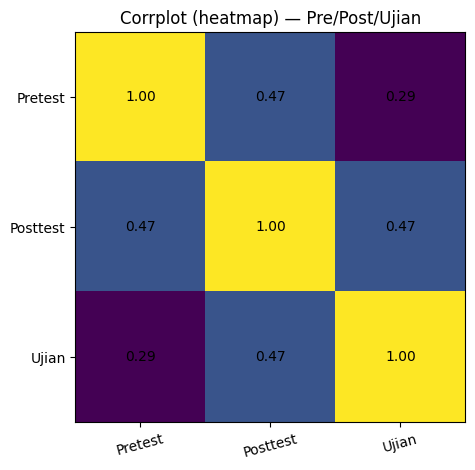

Bartlett Test of Sphericity:


,n,p,det(R),chi2,df,p_value
0,156,3,0.599611,78.340688,3,1.110223e-16


In [ ]:
X_raw = df[["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]].values
corr = np.corrcoef(X_raw.T)

plt.figure()
plt.imshow(corr, interpolation="nearest")
plt.xticks([0,1,2], ["Pretest","Posttest","Ujian"], rotation=15)
plt.yticks([0,1,2], ["Pretest","Posttest","Ujian"])
plt.title("Corrplot (heatmap) — Pre/Post/Ujian")
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center")
save_fig(os.path.join(OUT_STD_DIR, "06_corrplot.png"))
plt.show()

# Bartlett test (implementasi sendiri)
# Statistik: chi2 = -(n-1 - (2p+5)/6)*ln(det(R)), df = p(p-1)/2
n = X_raw.shape[0]
p = X_raw.shape[1]  # p=3 (pre, post, ujian)
detR = np.linalg.det(corr)
chi2_stat = - (n - 1 - (2*p + 5)/6) * np.log(detR) if detR > 0 else np.inf
df_bartlett = int(p*(p-1)/2)
p_value = 1 - chi2.cdf(chi2_stat, df_bartlett)

bart = pd.DataFrame([{
    "n": n, "p": p, "det(R)": detR,
    "chi2": chi2_stat, "df": df_bartlett, "p_value": p_value
}])
print("Bartlett Test of Sphericity:")
display(bart)
bart.to_csv(os.path.join(OUT_STD_DIR, "07_bartlett_test.csv"), index=False)

# 4.4 MODELING

***CELL 07 — Standardisasi fitur (untuk jarak Euclidean stabil)***

***Catatan rumus:***
- Rumus jarak Euclidean (2.2) digunakan pada ruang fitur X (p=3).
- StandardScaler dipakai agar tiap fitur kontribusinya seimbang.

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)  # X: n x p

scaler_info = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "features": ["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]
}
with open(os.path.join(OUT_STD_DIR, "08_scaler_params.json"), "w") as f:
    json.dump(scaler_info, f, indent=2)
print("Saved scaler params:", os.path.join(OUT_STD_DIR, "08_scaler_params.json"))

Saved scaler params: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/08_scaler_params.json


***CELL 08 — Penentuan K (Elbow SSE + Silhouette + DBI)***

,K,SSE,Silhouette,DBI
0,2,273.313259,0.399030,1.029348
1,3,211.065678,0.286443,1.157509
2,4,179.596225,0.288312,1.128363
3,5,154.952735,0.298967,1.068835
4,6,136.342381,0.272278,1.035394
5,7,120.722351,0.279185,1.028932
6,8,106.632550,0.293255,1.046018


Saved K metrics table: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/09_metrics_by_K.csv
Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/10_elbow_sse.png


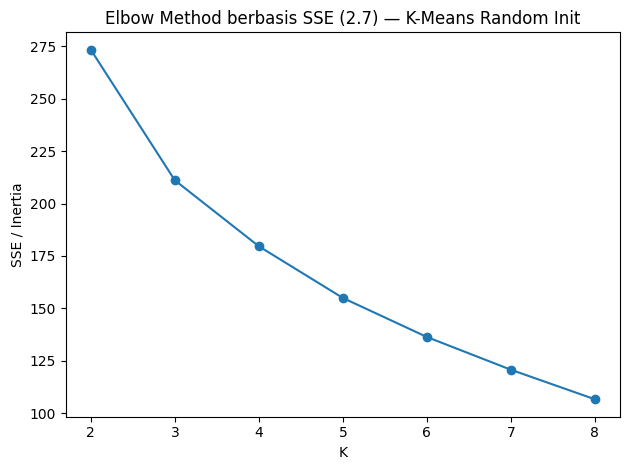

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/11_silhouette_vs_k.png


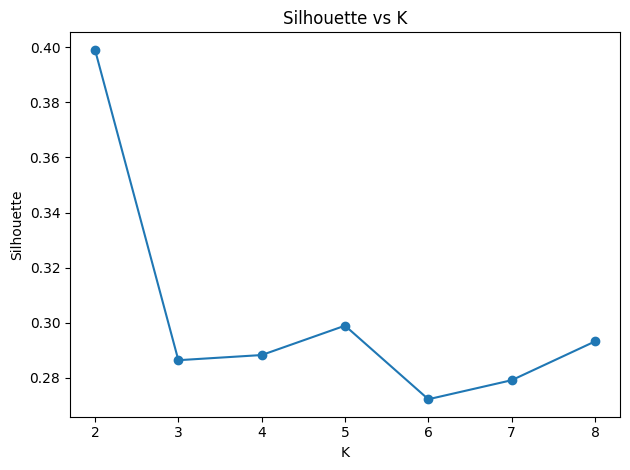

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/12_dbi_vs_k.png


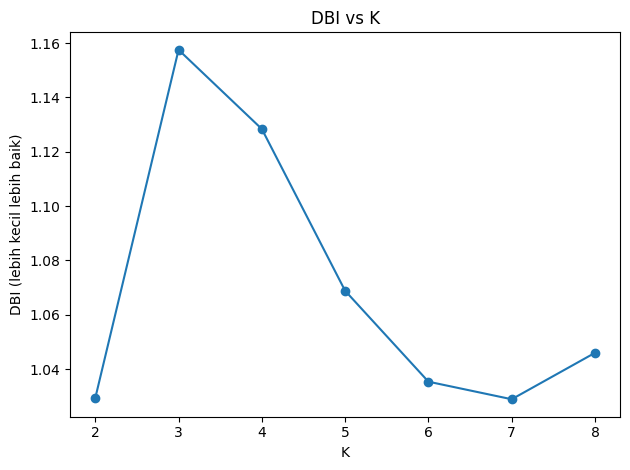

In [ ]:
rows = []
for k in range(K_MIN, K_MAX+1):
    km = KMeans(n_clusters=k, init="random", n_init=30, random_state=SEED, max_iter=500)
    labels = km.fit_predict(X)

    sse = float(km.inertia_)  # Implementasi rumus (2.1)/(2.7)
    sil = float(silhouette_score(X, labels)) if k > 1 else np.nan
    dbi = float(davies_bouldin_score(X, labels)) if k > 1 else np.nan

    rows.append({"K":k, "SSE":sse, "Silhouette":sil, "DBI":dbi})

metrics_k = pd.DataFrame(rows)
display(metrics_k)

OUT_K_TABLE = os.path.join(OUT_STD_DIR, "09_metrics_by_K.csv")
metrics_k.to_csv(OUT_K_TABLE, index=False)
print("Saved K metrics table:", OUT_K_TABLE)

# Plot Elbow (SSE)
plt.figure()
plt.plot(metrics_k["K"], metrics_k["SSE"], marker="o")
plt.xlabel("K"); plt.ylabel("SSE / Inertia")
plt.title("Elbow Method berbasis SSE (2.7) — K-Means Random Init")
save_fig(os.path.join(OUT_STD_DIR, "10_elbow_sse.png"))
plt.show()

# Plot Silhouette
plt.figure()
plt.plot(metrics_k["K"], metrics_k["Silhouette"], marker="o")
plt.xlabel("K"); plt.ylabel("Silhouette")
plt.title("Silhouette vs K")
save_fig(os.path.join(OUT_STD_DIR, "11_silhouette_vs_k.png"))
plt.show()

# Plot DBI
plt.figure()
plt.plot(metrics_k["K"], metrics_k["DBI"], marker="o")
plt.xlabel("K"); plt.ylabel("DBI (lebih kecil lebih baik)")
plt.title("DBI vs K")
save_fig(os.path.join(OUT_STD_DIR, "12_dbi_vs_k.png"))
plt.show()

***CELL 09 — Pilih K (otomatis sederhana + bisa override manual)***

- Heuristik sederhana: pilih K dengan Silhouette maksimum (sering stabil untuk p kecil)
- set manual kalau sudah tentukan dari elbow.

In [ ]:
K_OPT_AUTO = int(metrics_k.loc[metrics_k["Silhouette"].idxmax(), "K"])
K_OPT = K_OPT_AUTO  # <-- override manual jika perlu, misal: K_OPT = 3
print("K_OPT (auto by max silhouette):", K_OPT_AUTO, "| K_OPT dipakai:", K_OPT)

K_OPT (auto by max silhouette): 2 | K_OPT dipakai: 2


***CELL 10A — K-MEANS STANDAR (baseline 1-start) + metrik***

***Implementasi:***
- Jarak Euclidean (2.2): dilakukan internal oleh KMeans saat assignment
- Update centroid (2.3): dilakukan internal oleh KMeans
- SSE / inertia (2.1)/(2.7): km.inertia_

In [ ]:
# (A) Model standar baseline (paling “umum” & fair untuk dibanding SA)
km_std = KMeans(
    n_clusters=K_OPT,
    init="random",      # bukan K++
    n_init=1,           # 1 start (baseline)
    random_state=SEED,
    max_iter=500
)
labels_std = km_std.fit_predict(X)

sse_std = float(km_std.inertia_)  # (2.1)/(2.7) SSE = Σ||xi-μj||^2
sil_std = float(silhouette_score(X, labels_std))  # (2.8)-(2.9)
dbi_std = float(davies_bouldin_score(X, labels_std))  # (2.10)-(2.14) konsep DBI

print("K-Means Standar (baseline) | SSE:", sse_std, "| Sil:", sil_std, "| DBI:", dbi_std)

# centroid pada ruang scaled -> balik ke skala asli 0-100
cent_std_scaled = km_std.cluster_centers_
cent_std_raw = scaler.inverse_transform(cent_std_scaled)

centroids_std = pd.DataFrame(cent_std_raw, columns=["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"])
centroids_std.insert(0, "Cluster", range(K_OPT))
centroids_std = centroids_std.round(2)

# assignment
out_assign_std = df[["NPM","Nama","Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]].copy()
out_assign_std["Cluster"] = labels_std

# ============================================================
# (B) Relabel cluster agar cluster 0 = performa terendah
# ============================================================
# Ini hanya mengganti label agar interpretasi “Cluster 0 rendah” konsisten.
# Tidak mengubah struktur partisi, hanya permutasi label.

def relabel_by_overall_mean(assign_df, cent_df, feat_cols):
    # skor cluster = mean dari 3 fitur (pre+post+ujian)
    cent_df = cent_df.copy()
    cent_df["ScoreMean"] = cent_df[feat_cols].mean(axis=1)

    # urut dari rendah ke tinggi
    order = cent_df.sort_values("ScoreMean")["Cluster"].tolist()
    mapping = {old:i for i, old in enumerate(order)}  # cluster rendah -> 0

    assign_df = assign_df.copy()
    assign_df["Cluster"] = assign_df["Cluster"].map(mapping)

    cent_df["Cluster"] = cent_df["Cluster"].map(mapping)
    cent_df = cent_df.drop(columns=["ScoreMean"]).sort_values("Cluster").reset_index(drop=True)
    return assign_df, cent_df, mapping

FEATS = ["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]
out_assign_std, centroids_std, map_std = relabel_by_overall_mean(out_assign_std, centroids_std, FEATS)

# save centroid & counts
cluster_counts_std = out_assign_std["Cluster"].value_counts().sort_index().rename("Jumlah").reset_index().rename(columns={"index":"Cluster"})
display(centroids_std)
display(cluster_counts_std)

centroids_std.to_csv(os.path.join(OUT_STD_DIR, "14_centroids_kmeans_standard.csv"), index=False)
cluster_counts_std.to_csv(os.path.join(OUT_STD_DIR, "15_cluster_counts_kmeans_standard.csv"), index=False)

out_assign_std.to_csv(os.path.join(OUT_STD_DIR, "16_assignment_kmeans_standard.csv"), index=False)

# profil mean per cluster (skala asli)
profile_std = out_assign_std.groupby("Cluster")[FEATS].mean().round(2).reset_index()
profile_std.to_csv(os.path.join(OUT_STD_DIR, "17_cluster_profile_kmeans_standard.csv"), index=False)
display(profile_std)

K-Means Standar (baseline) | SSE: 273.50779835301455 | Sil: 0.3967324960719804 | DBI: 1.0469252526376223


,Cluster,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,0,41.95,39.22,45.68
1,1,69.48,67.01,61.32


,Cluster,Jumlah
0,0,51
1,1,105


,Cluster,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,0,41.95,39.22,45.68
1,1,69.48,67.01,61.32


***CELL 10B — Range (Min–Q1–Median–Q3–Max) + diagnosis komponen dominan (STD)***

,Cluster,N,Fitur,Min,Q1,Median,Q3,Max,Mean,Std,DeltaMean,ZDelta
0,0,51,Nilai_Pretest,10.71,29.23,40.29,52.88,82.14,41.95,17.13,-18.53,-0.97
1,0,51,Nilai_Posttest,11.42,28.30,36.11,50.14,74.87,39.22,15.24,-18.70,-1.00
2,0,51,Nilai_Ujian,22.70,38.02,44.83,52.98,82.71,45.68,12.46,-10.53,-0.79
3,1,105,Nilai_Pretest,19.83,63.30,71.43,78.57,91.67,69.48,12.46,9.00,0.47
4,1,105,Nilai_Posttest,36.11,58.94,69.30,75.00,92.86,67.01,12.33,9.08,0.49
5,1,105,Nilai_Ujian,37.93,55.17,62.07,68.00,86.21,61.32,10.36,5.11,0.38


Saved: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/17B_cluster_box_summary_std_LONG.csv
Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/17C_component_zdelta_std.png


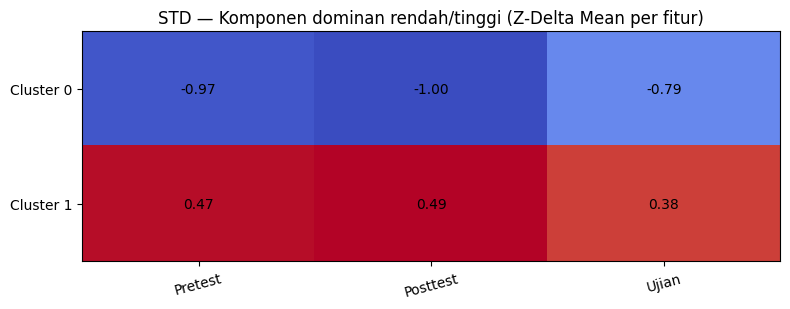

In [ ]:
# ============================================================
# LONG summary per Cluster x Fitur
# Output kolom:
# Cluster | N | Fitur | Min | Q1 | Median | Q3 | Max | Mean | Std | DeltaMean | ZDelta
# ============================================================

def cluster_box_summary_long(assign_df, feat_cols):
    rows = []

    # overall stats (untuk DeltaMean & ZDelta)
    overall_mean = assign_df[feat_cols].mean(numeric_only=True)
    overall_std  = assign_df[feat_cols].std(ddof=0, numeric_only=True).replace(0, np.nan)

    for cl in sorted(assign_df["Cluster"].unique()):
        sub = assign_df[assign_df["Cluster"] == cl]
        n = len(sub)

        for f in feat_cols:
            s = pd.to_numeric(sub[f], errors="coerce").dropna()
            if len(s) == 0:
                rows.append({
                    "Cluster": cl, "N": n, "Fitur": f,
                    "Min": np.nan, "Q1": np.nan, "Median": np.nan, "Q3": np.nan, "Max": np.nan,
                    "Mean": np.nan, "Std": np.nan, "DeltaMean": np.nan, "ZDelta": np.nan
                })
                continue

            mean_f = float(s.mean())
            std_f  = float(s.std(ddof=0))

            delta  = mean_f - float(overall_mean[f])
            zdelta = delta / float(overall_std[f]) if pd.notna(overall_std[f]) else np.nan

            rows.append({
                "Cluster": cl,
                "N": n,
                "Fitur": f,
                "Min": float(s.min()),
                "Q1": float(s.quantile(0.25)),
                "Median": float(s.median()),
                "Q3": float(s.quantile(0.75)),
                "Max": float(s.max()),
                "Mean": mean_f,
                "Std": std_f,
                "DeltaMean": float(delta),
                "ZDelta": float(zdelta) if pd.notna(zdelta) else np.nan
            })

    return pd.DataFrame(rows)


# ==== RUN (STD) ====
range_std_long = cluster_box_summary_long(out_assign_std, FEATS)

# pembulatan tampilan (2 desimal)
range_std_long_round = range_std_long.round(2)
display(range_std_long_round)

# simpan
OUT_LONG = os.path.join(OUT_STD_DIR, "17B_cluster_box_summary_std_LONG.csv")
range_std_long_round.to_csv(OUT_LONG, index=False)
print("Saved:", OUT_LONG)


# ============================================================
# Heatmap ZDelta (komponen dominan rendah/tinggi) dari LONG
# Baris = Cluster, Kolom = Fitur, Isi = ZDelta
# ============================================================

zmat_df = (
    range_std_long.pivot(index="Cluster", columns="Fitur", values="ZDelta")
    .reindex(columns=FEATS)  # urutkan kolom sesuai FEATS
)

zmat = zmat_df.values

plt.figure(figsize=(8, 3.2))
plt.imshow(zmat, aspect="auto", cmap="coolwarm")
plt.yticks(range(len(zmat_df.index)), [f"Cluster {c}" for c in zmat_df.index])
plt.xticks(range(len(zmat_df.columns)), ["Pretest","Posttest","Ujian"], rotation=15)

for i in range(zmat.shape[0]):
    for j in range(zmat.shape[1]):
        val = zmat[i, j]
        plt.text(j, i, f"{val:.2f}" if pd.notna(val) else "-", ha="center", va="center")

plt.title("STD — Komponen dominan rendah/tinggi (Z-Delta Mean per fitur)")
save_fig(os.path.join(OUT_STD_DIR, "17C_component_zdelta_std.png"))
plt.show()

***CELL 11 — Visualisasi K-Means Standar (scatter + centroid bintang)***

/tmp/ipython-input-4216368743.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_std["Cluster"].unique())], showmeans=True)


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/23_boxplot_Nilai_Pretest_std.png


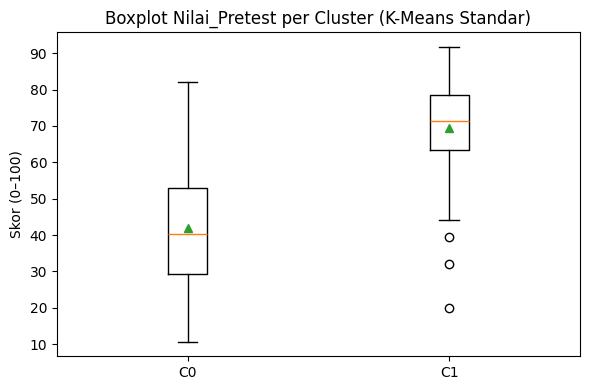

/tmp/ipython-input-4216368743.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_std["Cluster"].unique())], showmeans=True)


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/23_boxplot_Nilai_Posttest_std.png


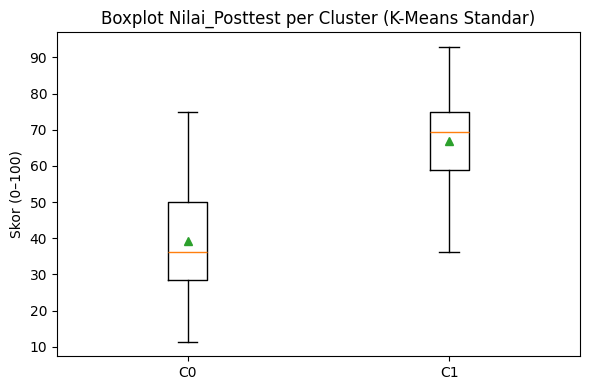

/tmp/ipython-input-4216368743.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_std["Cluster"].unique())], showmeans=True)


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/23_boxplot_Nilai_Ujian_std.png


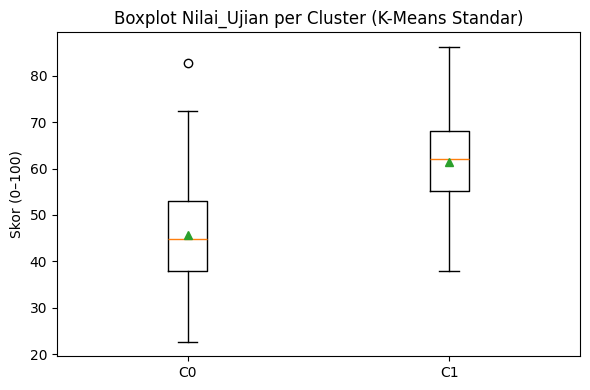

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/24_heatmap_centroids_std.png


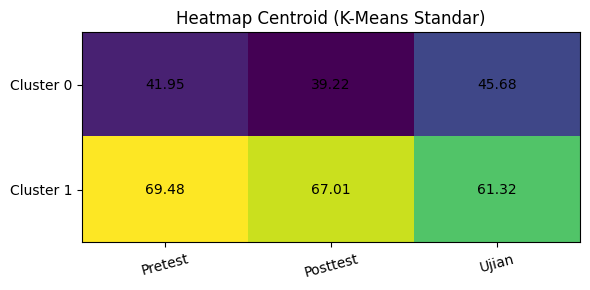

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/25_scatter_3d_std.png


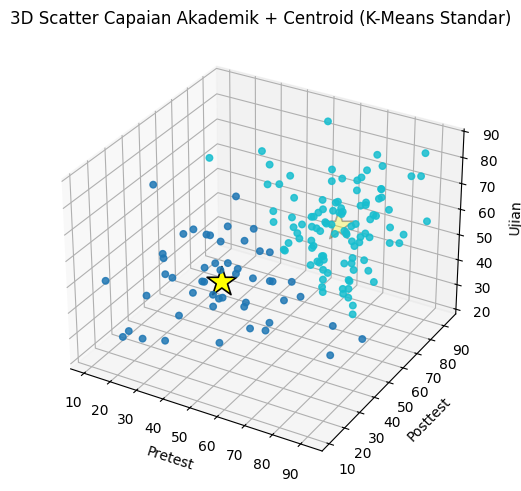

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/26_parallel_coordinates_std.png


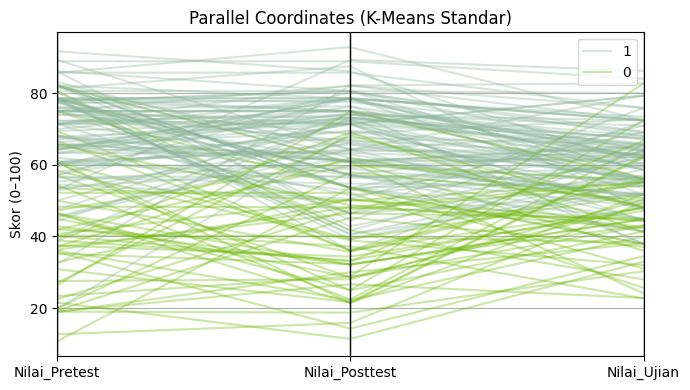

In [ ]:
FEAT_INDEX = {"Nilai_Pretest":0, "Nilai_Posttest":1, "Nilai_Ujian":2}

def scatter_with_centroids(df_plot, labels, cent_raw, xcol, ycol, title, out_path):
    xi = FEAT_INDEX[xcol]
    yi = FEAT_INDEX[ycol]

    plt.figure(figsize=(6,5))
    plt.scatter(df_plot[xcol], df_plot[ycol], c=labels, cmap="tab10", s=28, alpha=0.85)
    plt.scatter(cent_raw[:,xi], cent_raw[:,yi], marker="*", s=420, c="yellow",
                edgecolors="black", linewidths=1.2, zorder=5)
    plt.xlabel(xcol); plt.ylabel(ycol)
    plt.title(title)
    save_fig(out_path)
    plt.show()

# (1) Boxplot per fitur per cluster (jelas rentangnya)
for f in FEATS:
    plt.figure(figsize=(6,4))
    data = [out_assign_std[out_assign_std["Cluster"]==cl][f].values for cl in sorted(out_assign_std["Cluster"].unique())]
    plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_std["Cluster"].unique())], showmeans=True)
    plt.title(f"Boxplot {f} per Cluster (K-Means Standar)")
    plt.ylabel("Skor (0–100)")
    save_fig(os.path.join(OUT_STD_DIR, f"23_boxplot_{f}_std.png"))
    plt.show()

# (2) Heatmap centroid (profil klaster cepat kebaca)
cent_mat = centroids_std[FEATS].values
plt.figure(figsize=(6,3))
plt.imshow(cent_mat, aspect="auto")
plt.yticks(range(K_OPT), [f"Cluster {i}" for i in range(K_OPT)])
plt.xticks(range(len(FEATS)), ["Pretest","Posttest","Ujian"], rotation=15)
plt.title("Heatmap Centroid (K-Means Standar)")
for i in range(K_OPT):
    for j in range(len(FEATS)):
        plt.text(j, i, f"{cent_mat[i,j]:.2f}", ha="center", va="center")
save_fig(os.path.join(OUT_STD_DIR, "24_heatmap_centroids_std.png"))
plt.show()

# (3) 3D scatter (opsional, tapi sangat intuitif untuk p=3)
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(out_assign_std["Nilai_Pretest"], out_assign_std["Nilai_Posttest"], out_assign_std["Nilai_Ujian"],
           c=out_assign_std["Cluster"], cmap="tab10", s=22, alpha=0.85)
ax.scatter(centroids_std["Nilai_Pretest"], centroids_std["Nilai_Posttest"], centroids_std["Nilai_Ujian"],
           marker="*", s=500, c="yellow", edgecolors="black", linewidths=1.2)
ax.set_xlabel("Pretest"); ax.set_ylabel("Posttest"); ax.set_zlabel("Ujian")
ax.set_title("3D Scatter Capaian Akademik + Centroid (K-Means Standar)")
save_fig(os.path.join(OUT_STD_DIR, "25_scatter_3d_std.png"))
plt.show()

# (4) Parallel Coordinates (lihat pola 3 fitur sekaligus)
tmp = out_assign_std[["Cluster"]+FEATS].copy()
tmp["Cluster"] = tmp["Cluster"].astype(str)
plt.figure(figsize=(7,4))
pd.plotting.parallel_coordinates(tmp, class_column="Cluster", cols=FEATS, alpha=0.35)
plt.title("Parallel Coordinates (K-Means Standar)")
plt.ylabel("Skor (0–100)")
save_fig(os.path.join(OUT_STD_DIR, "26_parallel_coordinates_std.png"))
plt.show()


# ============================================================
# K-MEANS + SIMULATED ANNEALING (SA)

Inti: SA mengoptimasi inisialisasi centroid agar SSE akhir (2.1/2.7) turun & stabil.
***Rumus SA:***
1. ΔE = E(s') - E(s) (2.4)
2. P(terima)=exp(-ΔE/T) (2.5)
3.  T_{t+1}=αT_t (2.6)
# ============================================================


***CELL 12 — Fungsi utilitas SA (optimasi centroid init)***

In [ ]:
def kmeans_refine_from_centroids(X, centroids_init, K, max_iter=200, random_state=0):
    """
    Jalankan KMeans dengan init centroid tertentu (n_init=1) untuk refinement.
    - Assignment: jarak Euclidean (2.2) -> internal
    - Update centroid rata-rata (2.3) -> internal
    - Energi E(s) = SSE = inertia_ (2.1)/(2.7)
    """
    km = KMeans(n_clusters=K, init=centroids_init, n_init=1, max_iter=max_iter, random_state=random_state)
    labels = km.fit_predict(X)
    return km, labels, float(km.inertia_)

def estimate_T0(deltaEs, p0=0.8):
    """
    Estimasi T0 supaya peluang terima rata-rata ~ p0 untuk langkah buruk awal.
    dari (2.5): p0 ≈ exp(-ΔE/T0) => T0 ≈ -mean(ΔE)/ln(p0)
    """
    deltaEs = [d for d in deltaEs if d > 0]
    if len(deltaEs) == 0:
        return 1.0
    return float(-np.mean(deltaEs) / np.log(p0))

def simulated_annealing_optimize_init(X, K, base_centroids, T0=1.0, alpha=0.95,
                                     T_steps=60, iters_per_T=30, step_scale=0.15,
                                     seed=42, refine_max_iter=200):
    """
    Solusi s = konfigurasi centroid (di ruang standardisasi).
    Neighborhood: ganggu 1 centroid dengan noise Gaussian (skala step_scale).
    Energi: SSE setelah refinement KMeans (2.1)/(2.7).
    """
    rng = np.random.default_rng(seed)

    # solusi awal: base_centroids (misal dari best KMeans standar)
    curr_cent = base_centroids.copy()
    km_curr, lab_curr, E_curr = kmeans_refine_from_centroids(X, curr_cent, K, max_iter=refine_max_iter, random_state=seed)

    best_cent = curr_cent.copy()
    best_km   = km_curr
    best_lab  = lab_curr
    best_E    = E_curr

    log_rows = []
    T = float(T0)

    for t in range(T_steps):
        for it in range(iters_per_T):
            # buat neighbor s'
            cand_cent = curr_cent.copy()
            j = rng.integers(0, K)  # centroid mana yang diganggu
            cand_cent[j] = cand_cent[j] + rng.normal(0, step_scale, size=cand_cent[j].shape)

            # hitung energi kandidat E(s')
            km_cand, lab_cand, E_cand = kmeans_refine_from_centroids(X, cand_cent, K, max_iter=refine_max_iter, random_state=seed)

            # ΔE (2.4)
            dE = E_cand - E_curr

            # aturan penerimaan (2.5)
            accept = False
            if dE <= 0:
                accept = True
            else:
                p_accept = math.exp(-dE / T) if T > 1e-12 else 0.0
                if rng.random() < p_accept:
                    accept = True

            if accept:
                curr_cent = cand_cent
                km_curr, lab_curr, E_curr = km_cand, lab_cand, E_cand

            # simpan best (energi minimum)
            if E_cand < best_E:
                best_E = E_cand
                best_cent = cand_cent
                best_km = km_cand
                best_lab = lab_cand

            log_rows.append({
                "t_step": t,
                "iter": it,
                "T": T,
                "E_curr": E_curr,
                "E_cand": E_cand,
                "dE": dE,
                "accepted": int(accept),
                "best_E": best_E
            })

        # cooling (2.6)
        T = alpha * T

    log_df = pd.DataFrame(log_rows)
    return best_km, best_lab, best_E, best_cent, log_df

***CELL 13 A — Jalankan SA (parameter dibuat eksplisit & disimpan)***

baseline centroid dari KMeans standar terbaik (ruang scaled)

SA Params: {'T0': 1.0, 'alpha': 0.95, 'T_steps': 60, 'iters_per_T': 30, 'step_scale': 0.15}
K-Means + SA | SSE: 273.2792814648809 | Sil: 0.39672054989296524 | DBI: 1.0350707253883382
Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/02_sa_progress_best_sse.png


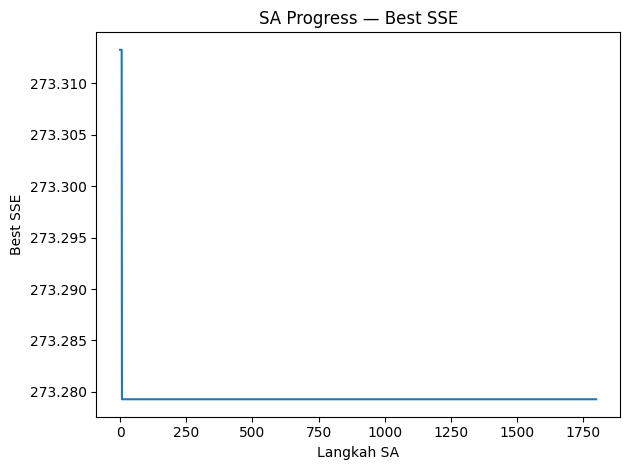

In [ ]:
base_centroids = cent_std_scaled.copy()

# Helper: Summary Range
def cluster_range_summary(assign_df, feat_cols):
    res = []
    for cl in sorted(assign_df['Cluster'].unique()):
        sub = assign_df[assign_df['Cluster'] == cl]
        row = {'Cluster': cl, 'Jumlah': len(sub)}
        for f in feat_cols:
            row[f"{f}_Min"] = sub[f].min()
            row[f"{f}_Max"] = sub[f].max()
        res.append(row)
    return pd.DataFrame(res)

# optional: estimasi T0 dari beberapa neighbor acak
tmp_delta = []
rng0 = np.random.default_rng(SEED)
for _ in range(30):
    cand = base_centroids.copy()
    j = rng0.integers(0, K_OPT)
    cand[j] = cand[j] + rng0.normal(0, 0.15, size=cand[j].shape)
    _, _, E_cand = kmeans_refine_from_centroids(X, cand, K_OPT, max_iter=200, random_state=SEED)
    # Gunakan sse_std sebagai pembanding jika 'best' tidak didefinisikan
    baseline_sse = sse_std
    tmp_delta.append(E_cand - baseline_sse)

T0 = estimate_T0(tmp_delta, p0=0.8)
SA_ALPHA = 0.95
SA_T_STEPS = 60
SA_ITERS_PER_T = 30
SA_STEP_SCALE = 0.15
SA_SEED = 2025

print("SA Params:", {"T0":T0, "alpha":SA_ALPHA, "T_steps":SA_T_STEPS, "iters_per_T":SA_ITERS_PER_T, "step_scale":SA_STEP_SCALE})

with open(os.path.join(OUT_SA_DIR, "00_sa_params.json"), "w") as f:
    json.dump({
        "K": K_OPT, "T0": T0, "alpha": SA_ALPHA, "T_steps": SA_T_STEPS,
        "iters_per_T": SA_ITERS_PER_T, "step_scale": SA_STEP_SCALE,
        "seed": SA_SEED, "refine_max_iter": 200
    }, f, indent=2)

km_sa, labels_sa, sse_sa, best_cent_sa, sa_log = simulated_annealing_optimize_init(
    X, K_OPT, base_centroids,
    T0=T0, alpha=SA_ALPHA, T_steps=SA_T_STEPS, iters_per_T=SA_ITERS_PER_T,
    step_scale=SA_STEP_SCALE, seed=SA_SEED, refine_max_iter=200
)

# metrik SA
sil_sa = float(silhouette_score(X, labels_sa))
dbi_sa = float(davies_bouldin_score(X, labels_sa))

print("K-Means + SA | SSE:", sse_sa, "| Sil:", sil_sa, "| DBI:", dbi_sa)

sa_log.to_csv(os.path.join(OUT_SA_DIR, "01_sa_log.csv"), index=False)

# assignment SA
out_assign_sa = df[["NPM","Nama","Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]].copy()
out_assign_sa["Cluster"] = labels_sa

# Simpan centroid SA pada skala asli
cent_sa_scaled = km_sa.cluster_centers_
cent_sa_raw = scaler.inverse_transform(cent_sa_scaled)

centroids_sa = pd.DataFrame(cent_sa_raw, columns=FEATS)
centroids_sa.insert(0, "Cluster", range(K_OPT))
centroids_sa = centroids_sa.round(2)

# Relabel cluster
out_assign_sa, centroids_sa, map_sa = relabel_by_overall_mean(out_assign_sa, centroids_sa, FEATS)

# Save files
centroids_sa.to_csv(os.path.join(OUT_SA_DIR, "03_centroids_kmeans_sa.csv"), index=False)
range_sa = cluster_range_summary(out_assign_sa, FEATS)
range_sa.to_csv(os.path.join(OUT_SA_DIR, "07B_cluster_range_summary_sa.csv"), index=False)

# Plot progress
plt.figure()
plt.plot(sa_log["best_E"].values)
plt.xlabel("Langkah SA"); plt.ylabel("Best SSE")
plt.title("SA Progress — Best SSE")
save_fig(os.path.join(OUT_SA_DIR, "02_sa_progress_best_sse.png"))
plt.show()

***CELL 13B — Sinkronisasi label & centroid SA + Range Box Summary (SA)***

,Cluster,Feature,N,Min,Q1,Median,Q3,Max,Mean,Std,ZDelta
0,0,Nilai_Posttest,50,11.42,28.17,36.11,49.68,74.87,38.79,15.08,-1.03
1,0,Nilai_Pretest,50,10.71,28.40,40.24,51.64,80.56,41.14,16.32,-1.01
2,0,Nilai_Ujian,50,22.70,38.13,44.93,53.62,82.71,46.11,12.20,-0.76
3,1,Nilai_Posttest,106,36.11,59.02,69.06,75.00,92.86,66.95,12.29,0.48
4,1,Nilai_Pretest,106,19.83,63.30,71.43,78.57,91.67,69.60,12.46,0.48
5,1,Nilai_Ujian,106,24.14,55.17,62.07,67.86,86.21,60.97,10.92,0.36


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/07D_component_zdelta_sa.png


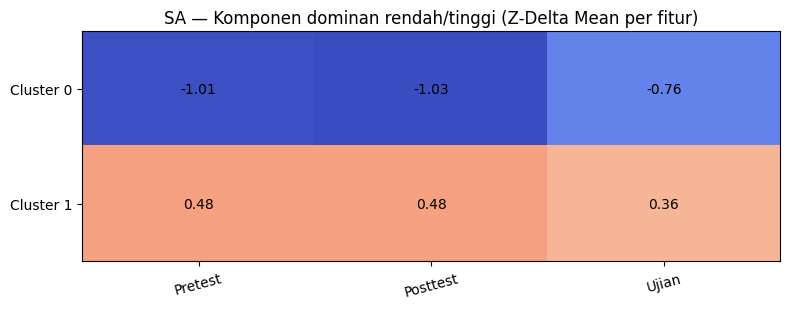

In [ ]:
# ============================================================
# SA — Ringkasan RENTANG per Cluster dalam format LONG (tidy)
# + Z-Delta (komponen dominan rendah/tinggi)
# ============================================================

# label final setelah relabel
labels_sa_final = out_assign_sa["Cluster"].values

# centroid raw final harus ambil dari centroids_sa (yang sudah relabel)
cent_sa_raw_final = centroids_sa.sort_values("Cluster")[FEATS].values

# (opsional) centroid scaled final
cent_sa_scaled_final = scaler.transform(cent_sa_raw_final)

def cluster_box_summary_long(assign_df: pd.DataFrame, feat_cols: list) -> pd.DataFrame:
    """
    Output LONG:
    Cluster | Feature | N | Min | Q1 | Median | Q3 | Max | Mean | Std | ZDelta

    ZDelta = (Mean_cluster - Mean_global) / Std_global
    -> interpretasi: ZDelta negatif = komponen relatif lebih rendah dari rata-rata global,
                     ZDelta positif = lebih tinggi.
    """
    df0 = assign_df.copy()

    # global mean/std per fitur (untuk ZDelta)
    gmean = {f: pd.to_numeric(df0[f], errors="coerce").mean() for f in feat_cols}
    gstd  = {f: pd.to_numeric(df0[f], errors="coerce").std(ddof=0) for f in feat_cols}

    rows = []
    for cl in sorted(df0["Cluster"].dropna().unique()):
        sub = df0[df0["Cluster"] == cl]
        for f in feat_cols:
            s = pd.to_numeric(sub[f], errors="coerce").dropna()
            if s.empty:
                continue

            q1 = float(s.quantile(0.25))
            q3 = float(s.quantile(0.75))
            med = float(s.median())
            mn = float(s.min())
            mx = float(s.max())
            mean = float(s.mean())
            std = float(s.std(ddof=0))

            denom = gstd[f] if (gstd[f] is not None and gstd[f] > 0) else np.nan
            zdelta = (mean - gmean[f]) / denom if denom == denom else np.nan  # NaN-safe

            rows.append({
                "Cluster": int(cl),
                "Feature": f,
                "N": int(len(s)),
                "Min": mn,
                "Q1": q1,
                "Median": med,
                "Q3": q3,
                "Max": mx,
                "Mean": mean,
                "Std": std,
                "ZDelta": float(zdelta) if zdelta == zdelta else np.nan
            })

    out = pd.DataFrame(rows).sort_values(["Cluster", "Feature"]).reset_index(drop=True)
    return out

# LONG summary untuk SA
range_sa_long = cluster_box_summary_long(out_assign_sa, FEATS).round(2)
display(range_sa_long)
range_sa_long.to_csv(os.path.join(OUT_SA_DIR, "07C_cluster_box_summary_sa_LONG.csv"), index=False)

# ============================================================
# Heatmap ZDelta (untuk baca komponen dominan) — dibuat dari LONG
# ============================================================

# Pivot hanya untuk plotting heatmap (data utama tetap LONG)
zmat_df = (
    range_sa_long.pivot(index="Cluster", columns="Feature", values="ZDelta")
    .reindex(sorted(out_assign_sa["Cluster"].unique()))
)

# pastikan urutan kolom sesuai FEATS
zmat_df = zmat_df[FEATS]

zmat = zmat_df.values
absmax = np.nanmax(np.abs(zmat)) if np.isfinite(np.nanmax(np.abs(zmat))) else 1.0

plt.figure(figsize=(8, 3.2))
plt.imshow(zmat, aspect="auto", cmap="coolwarm", vmin=-absmax, vmax=absmax)
plt.yticks(range(zmat_df.shape[0]), [f"Cluster {c}" for c in zmat_df.index])
plt.xticks(range(len(FEATS)), ["Pretest", "Posttest", "Ujian"], rotation=15)

for i in range(zmat.shape[0]):
    for j in range(zmat.shape[1]):
        plt.text(j, i, f"{zmat[i, j]:.2f}", ha="center", va="center")

plt.title("SA — Komponen dominan rendah/tinggi (Z-Delta Mean per fitur)")
save_fig(os.path.join(OUT_SA_DIR, "07D_component_zdelta_sa.png"))
plt.show()

***CELL 14A — Visualisasi K-Means + SA (scatter + centroid bintang + PCA)***

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/07_scatter_pre_post_sa.png


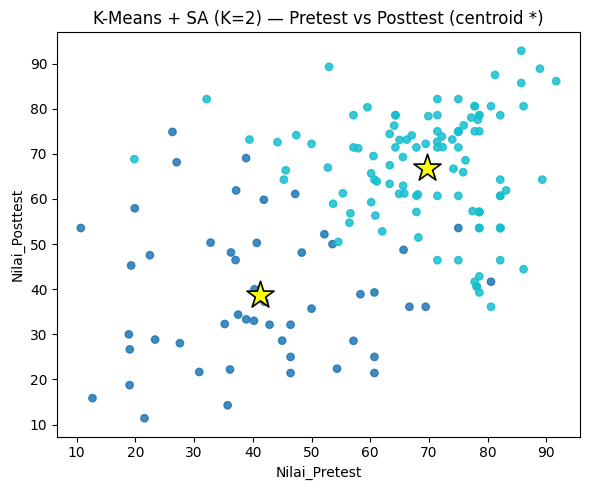

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/08_scatter_pre_ujian_sa.png


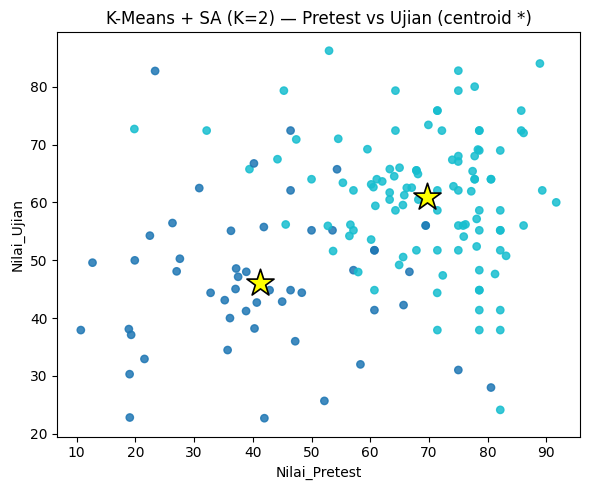

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/09_scatter_post_ujian_sa.png


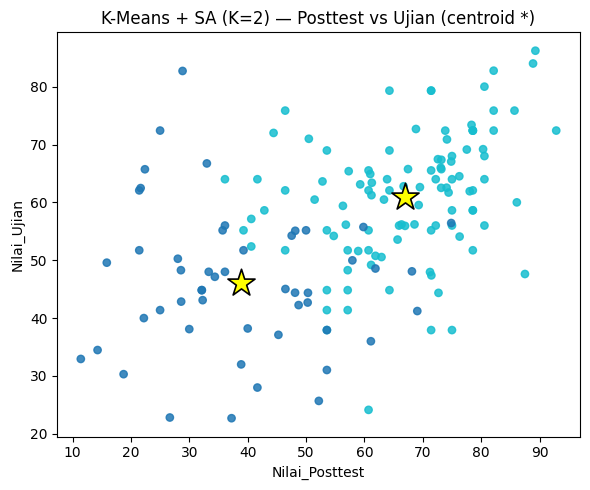

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/10_pca_cluster_sa.png


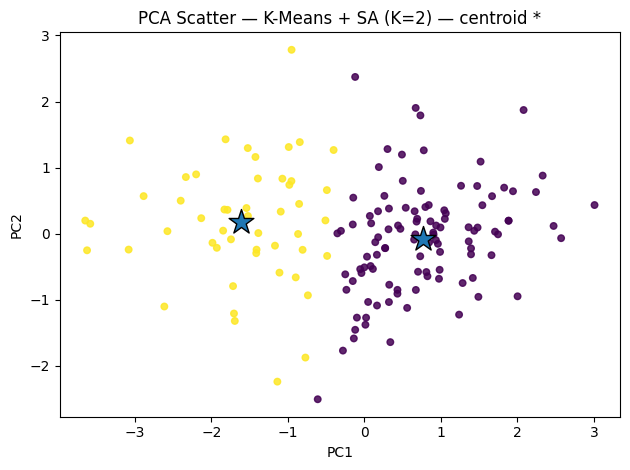

In [ ]:
cent_raw_arr_sa = cent_sa_raw
df_plot_sa = out_assign_sa.copy()

scatter_with_centroids(out_assign_sa, labels_sa_final, cent_sa_raw_final,
                       "Nilai_Pretest","Nilai_Posttest",
                       f"K-Means + SA (K={K_OPT}) — Pretest vs Posttest (centroid *)",
                       os.path.join(OUT_SA_DIR, "07_scatter_pre_post_sa.png"))

scatter_with_centroids(out_assign_sa, labels_sa_final, cent_sa_raw_final,
                       "Nilai_Pretest","Nilai_Ujian",
                       f"K-Means + SA (K={K_OPT}) — Pretest vs Ujian (centroid *)",
                       os.path.join(OUT_SA_DIR, "08_scatter_pre_ujian_sa.png"))

scatter_with_centroids(out_assign_sa, labels_sa_final, cent_sa_raw_final,
                       "Nilai_Posttest","Nilai_Ujian",
                       f"K-Means + SA (K={K_OPT}) — Posttest vs Ujian (centroid *)",
                       os.path.join(OUT_SA_DIR, "09_scatter_post_ujian_sa.png"))


pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X)
cent_pca_sa = pca2.transform(cent_sa_scaled)

plt.figure()
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_sa, s=22, alpha=0.85)
plt.scatter(cent_pca_sa[:,0], cent_pca_sa[:,1], marker="*", s=350, edgecolors="black")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA Scatter — K-Means + SA (K={K_OPT}) — centroid *")
save_fig(os.path.join(OUT_SA_DIR, "10_pca_cluster_sa.png"))
plt.show()

pca2_info = pd.DataFrame({
    "PC": ["PC1","PC2"],
    "Explained_Variance_Ratio": pca2.explained_variance_ratio_
})
pca2_info.to_csv(os.path.join(OUT_SA_DIR, "11_pca_variance_sa.csv"), index=False)


***CELL 14B — Visualisasi SA lengkap (range & sebaran) — fokus “dari berapa sampai berapa”***

/tmp/ipython-input-2976765473.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_sa["Cluster"].unique())], showmeans=True)


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/08_boxplot_Nilai_Pretest_sa.png


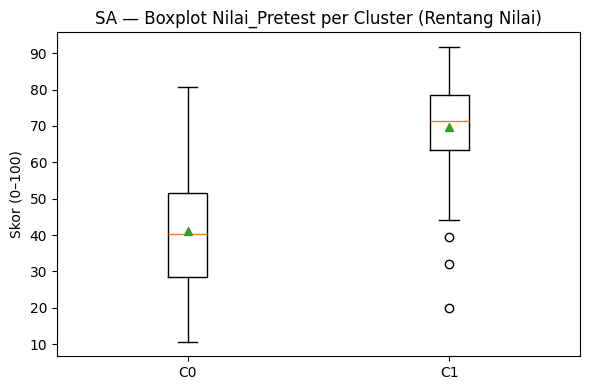

/tmp/ipython-input-2976765473.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_sa["Cluster"].unique())], showmeans=True)


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/08_boxplot_Nilai_Posttest_sa.png


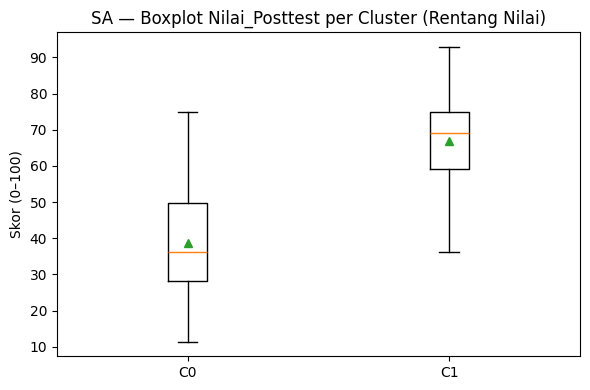

/tmp/ipython-input-2976765473.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_sa["Cluster"].unique())], showmeans=True)


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/08_boxplot_Nilai_Ujian_sa.png


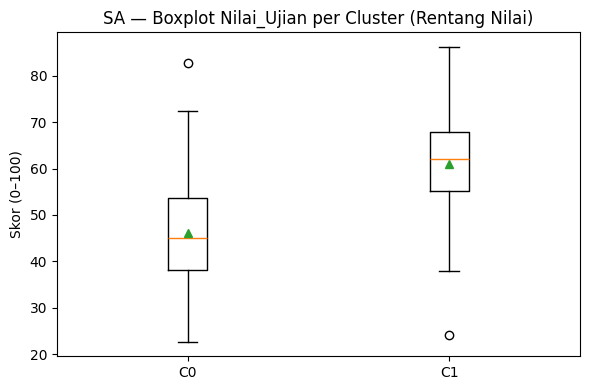

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/09_heatmap_centroids_sa.png


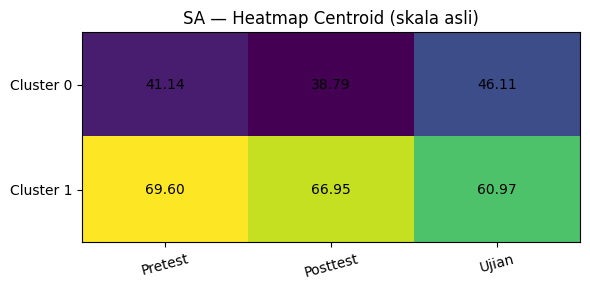

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/10_scatter_3d_sa.png


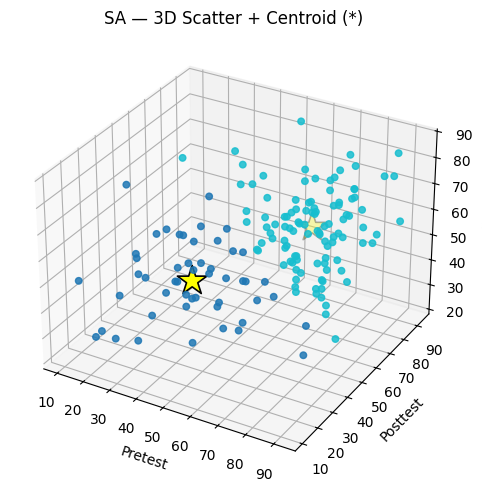

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/11_parallel_coordinates_sa.png


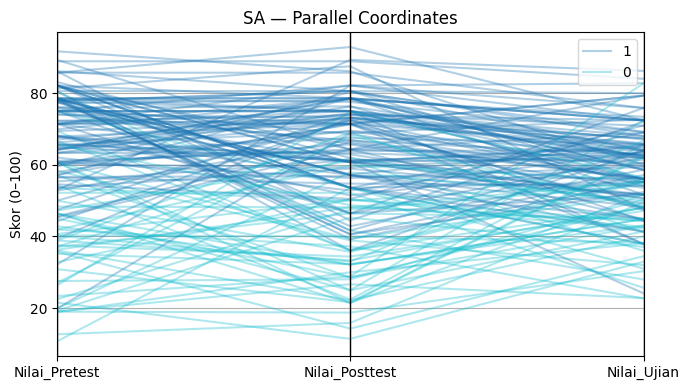

In [ ]:
# (1) Boxplot per fitur per cluster (SA) -> ini langsung menunjukkan min-Q1-median-Q3-max
for f in FEATS:
    plt.figure(figsize=(6,4))
    data = [out_assign_sa[out_assign_sa["Cluster"]==cl][f].values for cl in sorted(out_assign_sa["Cluster"].unique())]
    plt.boxplot(data, labels=[f"C{cl}" for cl in sorted(out_assign_sa["Cluster"].unique())], showmeans=True)
    plt.title(f"SA — Boxplot {f} per Cluster (Rentang Nilai)")
    plt.ylabel("Skor (0–100)")
    save_fig(os.path.join(OUT_SA_DIR, f"08_boxplot_{f}_sa.png"))
    plt.show()

# (2) Heatmap centroid SA (ringkas, tapi tetap bantu interpretasi cepat)
cent_mat_sa = centroids_sa.sort_values("Cluster")[FEATS].values
plt.figure(figsize=(6,3))
plt.imshow(cent_mat_sa, aspect="auto")
plt.yticks(range(K_OPT), [f"Cluster {i}" for i in range(K_OPT)])
plt.xticks(range(len(FEATS)), ["Pretest","Posttest","Ujian"], rotation=15)
plt.title("SA — Heatmap Centroid (skala asli)")
for i in range(K_OPT):
    for j in range(len(FEATS)):
        plt.text(j, i, f"{cent_mat_sa[i,j]:.2f}", ha="center", va="center")
save_fig(os.path.join(OUT_SA_DIR, "09_heatmap_centroids_sa.png"))
plt.show()

# (3) 3D scatter SA (intuitif untuk p=3)
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(out_assign_sa["Nilai_Pretest"], out_assign_sa["Nilai_Posttest"], out_assign_sa["Nilai_Ujian"],
           c=labels_sa_final, cmap="tab10", s=22, alpha=0.85)
ax.scatter(cent_sa_raw_final[:,0], cent_sa_raw_final[:,1], cent_sa_raw_final[:,2],
           marker="*", s=500, c="yellow", edgecolors="black", linewidths=1.2)
ax.set_xlabel("Pretest"); ax.set_ylabel("Posttest"); ax.set_zlabel("Ujian")
ax.set_title("SA — 3D Scatter + Centroid (*)")
save_fig(os.path.join(OUT_SA_DIR, "10_scatter_3d_sa.png"))
plt.show()

# (4) Parallel coordinates SA (pola 3 fitur)
tmp = out_assign_sa[["Cluster"]+FEATS].copy()
tmp["Cluster"] = tmp["Cluster"].astype(str)
plt.figure(figsize=(7,4))
pd.plotting.parallel_coordinates(tmp, class_column="Cluster", cols=FEATS, alpha=0.35, colormap="tab10")
plt.title("SA — Parallel Coordinates")
plt.ylabel("Skor (0–100)")
save_fig(os.path.join(OUT_SA_DIR, "11_parallel_coordinates_sa.png"))
plt.show()

# ============================================================
# 4.5 EVALUATION

***CELL 15 — Tabel perbandingan Standar vs SA + bukti dampak***

4.5 EVALUATION — PERBANDINGAN HASIL


,Model,K,SSE,Silhouette,DBI
0,K-Means Standar,2,273.51,0.3967,1.0469
1,K-Means + SA,2,273.28,0.3967,1.0351


Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/13_compare_sse.png


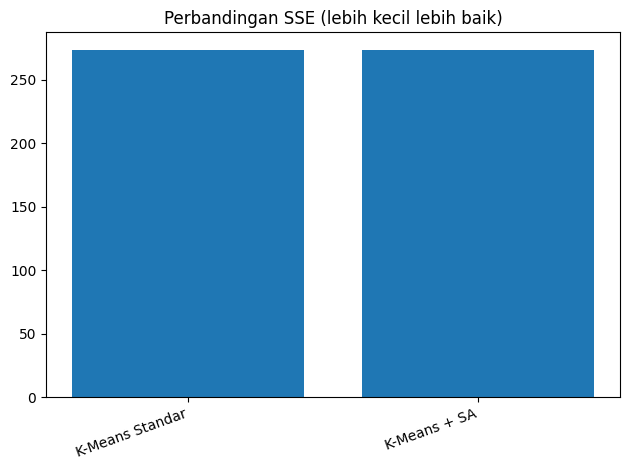

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/14_compare_silhouette.png


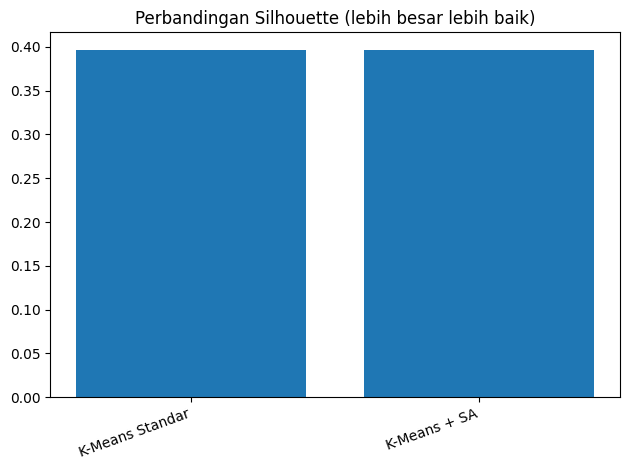

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/15_compare_dbi.png


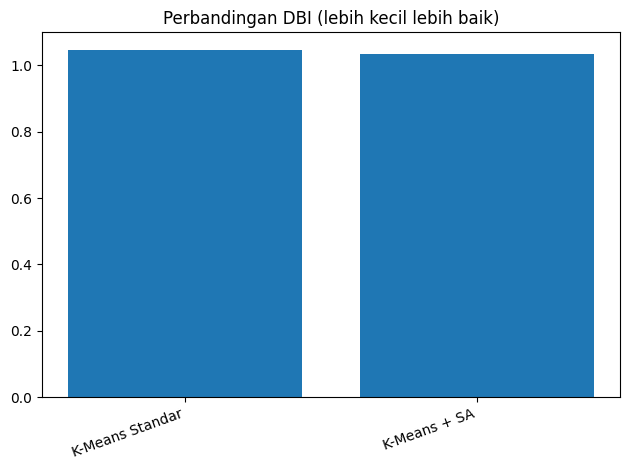

Saved figure: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/17_sse_distribution_std_vs_sa.png


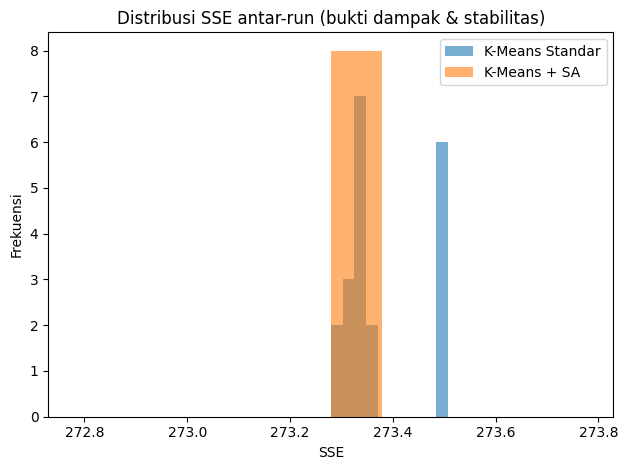

,Model,SSE_mean,SSE_std
0,K-Means Standar,273.38,0.09
1,K-Means + SA,273.28,0.00


In [ ]:
eval_table = pd.DataFrame([
    {"Model":"K-Means Standar", "K":K_OPT, "SSE":sse_std, "Silhouette":sil_std, "DBI":dbi_std},
    {"Model":"K-Means + SA",    "K":K_OPT, "SSE":sse_sa,      "Silhouette":sil_sa,           "DBI":dbi_sa},
])

# pembulatan 2 angka untuk metrik (SSE tetap float, tapi bisa juga dibulatkan)
eval_table_round = eval_table.copy()
eval_table_round["SSE"] = eval_table_round["SSE"].round(2)
eval_table_round["Silhouette"] = eval_table_round["Silhouette"].round(4)
eval_table_round["DBI"] = eval_table_round["DBI"].round(4)

print("="*110)
print("4.5 EVALUATION — PERBANDINGAN HASIL")
print("="*110)
display(eval_table_round)

eval_table_round.to_csv(os.path.join(OUT_STD_DIR, "18_evaluation_compare_standard_vs_sa.csv"), index=False)
eval_table_round.to_csv(os.path.join(OUT_SA_DIR,  "12_evaluation_compare_standard_vs_sa.csv"), index=False)

# Visual perbandingan metrik
plt.figure()
plt.bar(eval_table_round["Model"], eval_table_round["SSE"])
plt.title("Perbandingan SSE (lebih kecil lebih baik)")
plt.xticks(rotation=20, ha="right")
save_fig(os.path.join(OUT_SA_DIR, "13_compare_sse.png"))
plt.show()

plt.figure()
plt.bar(eval_table_round["Model"], eval_table_round["Silhouette"])
plt.title("Perbandingan Silhouette (lebih besar lebih baik)")
plt.xticks(rotation=20, ha="right")
save_fig(os.path.join(OUT_SA_DIR, "14_compare_silhouette.png"))
plt.show()

plt.figure()
plt.bar(eval_table_round["Model"], eval_table_round["DBI"])
plt.title("Perbandingan DBI (lebih kecil lebih baik)")
plt.xticks(rotation=20, ha="right")
save_fig(os.path.join(OUT_SA_DIR, "15_compare_dbi.png"))
plt.show()

# Bukti tambahan dampak SA: bandingkan distribusi SSE antar-run (standar) vs SA
def multi_run_kmeans_standard(X, K, n_runs=20):
    res=[]
    for rs in range(n_runs):
        km = KMeans(n_clusters=K, init="random", n_init=1, random_state=1000+rs, max_iter=500)
        lab = km.fit_predict(X)
        res.append({"run": rs, "SSE": float(km.inertia_), "Silhouette": float(silhouette_score(X, lab)), "DBI": float(davies_bouldin_score(X, lab))})
    return pd.DataFrame(res)

def multi_run_sa(X, K, base_centroids, n_runs=8):
    res=[]
    for rr in range(n_runs):
        km_sa_, lab_sa_, sse_sa_, _, _ = simulated_annealing_optimize_init(
            X, K, base_centroids, T0=T0, alpha=SA_ALPHA, T_steps=SA_T_STEPS, iters_per_T=SA_ITERS_PER_T,
            step_scale=SA_STEP_SCALE, seed=SA_SEED+rr, refine_max_iter=200
        )
        res.append({"run": rr, "SSE": float(sse_sa_), "Silhouette": float(silhouette_score(X, lab_sa_)), "DBI": float(davies_bouldin_score(X, lab_sa_))})
    return pd.DataFrame(res)

std_multi = multi_run_kmeans_standard(X, K_OPT, n_runs=20)
sa_multi  = multi_run_sa(X, K_OPT, base_centroids, n_runs=8)

std_multi.to_csv(os.path.join(OUT_STD_DIR, "19_std_multi_runs.csv"), index=False)
sa_multi.to_csv(os.path.join(OUT_SA_DIR,  "16_sa_multi_runs.csv"), index=False)

plt.figure()
plt.hist(std_multi["SSE"], bins=10, alpha=0.6, label="K-Means Standar")
plt.hist(sa_multi["SSE"],  bins=10, alpha=0.6, label="K-Means + SA")
plt.title("Distribusi SSE antar-run (bukti dampak & stabilitas)")
plt.xlabel("SSE"); plt.ylabel("Frekuensi")
plt.legend()
save_fig(os.path.join(OUT_SA_DIR, "17_sse_distribution_std_vs_sa.png"))
plt.show()

summary_stability = pd.DataFrame([
    {"Model":"K-Means Standar", "SSE_mean":std_multi["SSE"].mean(), "SSE_std":std_multi["SSE"].std()},
    {"Model":"K-Means + SA",    "SSE_mean":sa_multi["SSE"].mean(),  "SSE_std":sa_multi["SSE"].std()},
]).round(2)
display(summary_stability)
summary_stability.to_csv(os.path.join(OUT_SA_DIR, "18_stability_summary.csv"), index=False)

***CELL 16 — Simpan dataset final berlabel klaster (untuk profiling & rekomendasi)***

In [ ]:
deploy_std = out_assign_std.copy()
deploy_sa  = out_assign_sa.copy()

deploy_std.to_csv(os.path.join(OUT_STD_DIR, "20_deploy_dataset_with_cluster_standard.csv"), index=False)
deploy_sa.to_csv(os.path.join(OUT_SA_DIR,  "19_deploy_dataset_with_cluster_sa.csv"), index=False)

print("Deployment saved:")
print("- Standar:", os.path.join(OUT_STD_DIR, "20_deploy_dataset_with_cluster_standard.csv"))
print("- SA     :", os.path.join(OUT_SA_DIR,  "19_deploy_dataset_with_cluster_sa.csv"))

print("\nSelesai. Folder output berisi:")
print("K-Means Standar:", OUT_STD_DIR)
print("K-Means + SA   :", OUT_SA_DIR)

Deployment saved:
- Standar: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR/20_deploy_dataset_with_cluster_standard.csv
- SA     : /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/19_deploy_dataset_with_cluster_sa.csv

Selesai. Folder output berisi:
K-Means Standar: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS STANDAR
K-Means + SA   : /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING


***Informasi Dataset***

In [ ]:
# ============================================================
# INFORMASI DATASET (SETELAH CLUSTERING)
# ============================================================

def dataset_info(df, title="INFO DATASET"):
    print("="*110)
    print(title)
    print("="*110)
    print("Shape (baris, kolom):", df.shape)
    print("\nKolom:", list(df.columns))

    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype").reset_index().rename(columns={"index":"Kolom"}))

    print("\nMissing per kolom:")
    miss = df.isna().sum().to_frame("Missing_Count")
    miss["Missing_Rate"] = (df.isna().mean() * 100).round(2)
    display(miss)

    if "NPM" in df.columns:
        dup_npm = int(df["NPM"].duplicated().sum())
        print("\nDuplikasi NPM:", dup_npm)

    print("\nPreview 5 baris:")
    display(df.head(5))

# Menggunakan out_assign_sa (hasil clustering K-Means + SA)
dataset_info(out_assign_sa, title="INFORMASI DATASET — HASIL CLUSTERING (PRE/POST/UJIAN)")

INFORMASI DATASET — HASIL CLUSTERING (PRE/POST/UJIAN)
Shape (baris, kolom): (156, 6)

Kolom: ['NPM', 'Nama', 'Nilai_Pretest', 'Nilai_Posttest', 'Nilai_Ujian', 'Cluster']

Dtypes:


,Kolom,dtype
0,NPM,object
1,Nama,object
2,Nilai_Pretest,float64
3,Nilai_Posttest,float64
4,Nilai_Ujian,float64
5,Cluster,int64



Missing per kolom:


,Missing_Count,Missing_Rate
NPM,0,0.0
Nama,0,0.0
Nilai_Pretest,0,0.0
Nilai_Posttest,0,0.0
Nilai_Ujian,0,0.0
Cluster,0,0.0



Duplikasi NPM: 0

Preview 5 baris:


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian,Cluster
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14,1
1,G1F022002,Ulfa,38.89,33.33,48.00,0
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07,1
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.00,0
4,G1F022008,Meisy Dianita,88.89,88.89,84.00,1


In [ ]:
# ============================================================
# Statistik deskriptif per cluster (LONG)
# Output: Cluster | Fitur | mean | std | min | max
# ============================================================

# Menggunakan out_assign_sa sebagai pengganti df_cluster yang tidak terdefinisi
df_cluster_final = out_assign_sa
num_cols = [c for c in ["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"] if c in df_cluster_final.columns]

# 1. Aggregation creates MultiIndex columns
tmp_agg = (
    df_cluster_final
    .groupby("Cluster")[num_cols]
    .agg(["mean","std","min","max"])
)

# 2. Flatten MultiIndex columns: ('Nilai_Pretest', 'mean') -> 'Nilai_Pretest_mean'
tmp_agg.columns = ["_".join(col).strip() for col in tmp_agg.columns.values]
tmp_agg = tmp_agg.reset_index()

# 3. Melt now works because column names are flat strings
tmp_long = tmp_agg.melt(
    id_vars=["Cluster"],
    var_name="Fitur_Stat",
    value_name="Nilai"
)

# 4. pecah "Nilai_Pretest_mean" -> Fitur="Nilai_Pretest", Stat="mean"
tmp_long[["Fitur","Stat"]] = tmp_long["Fitur_Stat"].str.rsplit("_", n=1, expand=True)
tmp_long = tmp_long.drop(columns=["Fitur_Stat"])

# 5. pivot supaya Stat jadi kolom
tmp_long = (
    tmp_long.pivot_table(index=["Cluster","Fitur"], columns="Stat", values="Nilai", aggfunc="first")
    .reset_index()
)

# rapikan urutan kolom dan pembulatan
tmp_long = tmp_long[["Cluster","Fitur","mean","std","min","max"]].copy()
tmp_long[["mean","std","min","max"]] = tmp_long[["mean","std","min","max"]].round(2)

# (opsional) urutkan fitur biar rapi
order_feat = ["Nilai_Pretest","Nilai_Posttest","Nilai_Ujian"]
tmp_long["Fitur"] = pd.Categorical(tmp_long["Fitur"], categories=order_feat, ordered=True)
tmp_long = tmp_long.sort_values(["Cluster","Fitur"]).reset_index(drop=True)

print("\nStatistik deskriptif per cluster (LONG):")
display(tmp_long)

# kalau mau simpan
OUT_LONG_STATS = os.path.join(OUT_SA_DIR, "stats_per_cluster_long_sa.csv")
tmp_long.to_csv(OUT_LONG_STATS, index=False)
print("Saved:", OUT_LONG_STATS)


Statistik deskriptif per cluster (LONG):


Stat,Cluster,Fitur,mean,std,min,max
0,0,Nilai_Pretest,41.14,16.48,10.71,80.56
1,0,Nilai_Posttest,38.79,15.23,11.42,74.87
2,0,Nilai_Ujian,46.11,12.32,22.70,82.71
3,1,Nilai_Pretest,69.60,12.52,19.83,91.67
4,1,Nilai_Posttest,66.95,12.34,36.11,92.86
5,1,Nilai_Ujian,60.97,10.97,24.14,86.21


Saved: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Modelling/K-MEANS + SIMULATED ANNEALING/stats_per_cluster_long_sa.csv


***Visualisasi jumlah anggota Cluster 0 & 1***

,Jumlah,Persen
Cluster,,
0,50,32.05
1,106,67.95


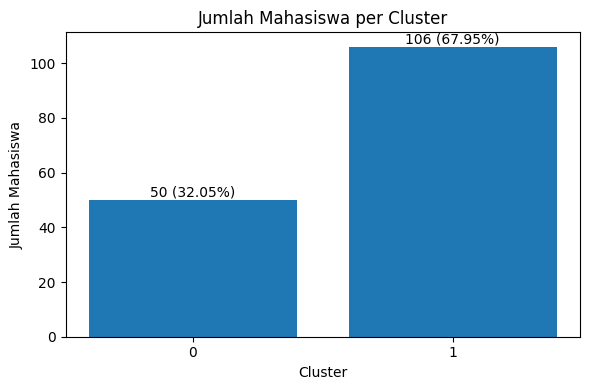

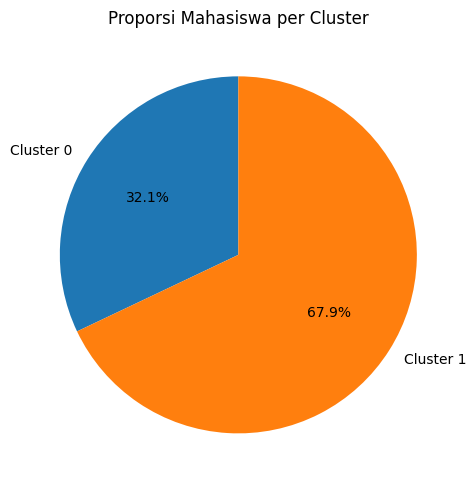

In [ ]:
# ============================================================
# VISUALISASI JUMLAH ANGGOTA CLUSTER 0 & 1
# ============================================================

# Menggunakan out_assign_sa (hasil clustering K-Means + SA)
df_viz = out_assign_sa

# pastikan kolom Cluster ada
assert "Cluster" in df_viz.columns, "Kolom 'Cluster' tidak ditemukan."

counts = df_viz["Cluster"].value_counts().sort_index()
counts_df = counts.rename("Jumlah").to_frame()
counts_df["Persen"] = (counts_df["Jumlah"] / counts_df["Jumlah"].sum() * 100).round(2)
display(counts_df)

# --- BAR CHART (jelas + ada label angka) ---
plt.figure(figsize=(6,4))
bars = plt.bar(counts_df.index.astype(str), counts_df["Jumlah"].values)
plt.title("Jumlah Mahasiswa per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Mahasiswa")

# label angka di atas batang
for i, v in enumerate(counts_df["Jumlah"].values):
    pct = counts_df["Persen"].iloc[i]
    plt.text(i, v, f"{v} ({pct}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# --- PIE CHART (opsional, untuk cepat lihat proporsi) ---
plt.figure(figsize=(5,5))
plt.pie(
    counts_df["Jumlah"].values,
    labels=[f"Cluster {i}" for i in counts_df.index],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporsi Mahasiswa per Cluster")
plt.tight_layout()
plt.show()